# <span style="color:red">  Monthly Data - EBC creation, FMB Quantiles (2000-2024)

#### Import all our packages and functions

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"


In [3]:
import importlib
import src.preference_factors.build_datasets as bd
import src.FamaMacBeth.betas as fmb_betas
import src.FamaMacBeth.pipeline as fmb_pipe
import src.FamaMacBeth.cross_sectional_regression as fmb_csr
import src.FamaMacBeth.pricing as fmb_pricing
import src.FamaMacBeth.backtest as fmb_backtest
import src.FamaMacBeth.plots as fmb_plots

# Reload the modules themselves
importlib.reload(bd)
importlib.reload(fmb_betas)
importlib.reload(fmb_pipe)
importlib.reload(fmb_csr)
importlib.reload(fmb_pricing)
importlib.reload(fmb_backtest)
importlib.reload(fmb_plots)


<module 'src.FamaMacBeth.plots' from '/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/plots.py'>

# <span style="color:red"> Create CSV's for Monthly EBC Weights, Beta Contributions, EBC returns, Preference Returns, Full preference and factors returns (Raw returns) </span>

In [4]:
merged_df, full_merged_df = bd.build_all_dataset(
    returns_file="sp500_returns_monthly_with_tickers.csv",
    market_caps_file="sp500_market_caps_monthly.csv",
    ff_factors_file="ff_factors_monthly.csv",
    frequency="monthly"
)

# Use raw (non-excess) EBC and CW-EBC spread
ebc = full_merged_df["EBC"]
cw_ebc = full_merged_df["CW"] - full_merged_df["EBC"]

Rolling OLS CAPM:   0%|          | 0/702 [00:00<?, ?it/s]

EBC optimization (parallel):   0%|          | 0/702 [00:00<?, ?it/s]

Hey fixing full investment every period


# <span style="color:red">  Check our results: cumulative returns, rolling market beta, compare our portfolios to ETF benchmarks (limited data)

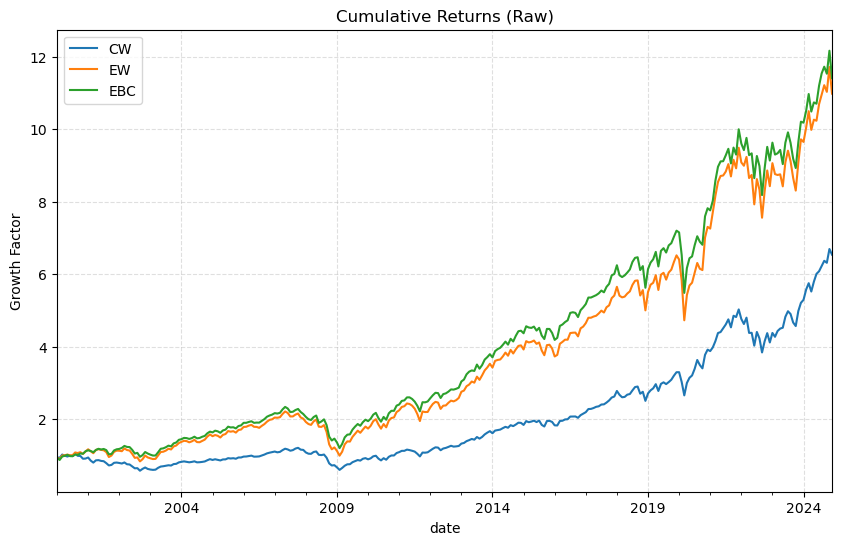

In [5]:
plot_df = full_merged_df[['CW', 'EW', 'EBC']].loc['2000':]
if isinstance(plot_df.index, pd.PeriodIndex):
    plot_df.index = plot_df.index.to_timestamp()
(1 + plot_df).cumprod().plot(figsize=(10, 6))
plt.title("Cumulative Returns (Raw)")
plt.ylabel("Growth Factor")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [6]:
full_merged_df['MKT'] = full_merged_df['MKT_RF'] + full_merged_df['RF']

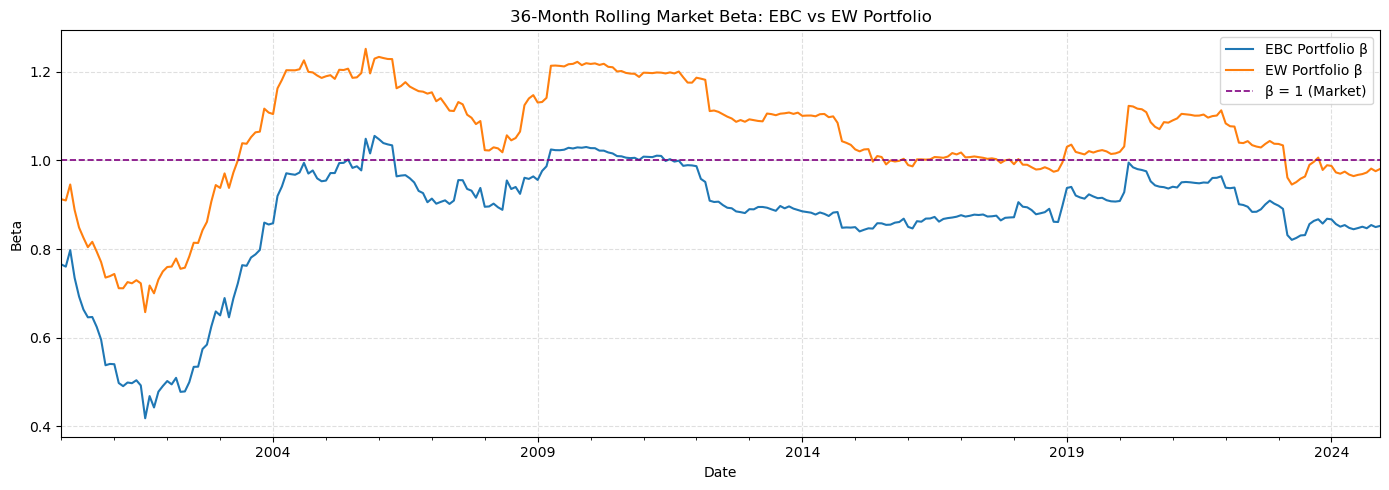


── Rolling Beta Summary ──
         EBC β     EW β
count  300.000  300.000
mean     0.874    1.051
std      0.136    0.127
min      0.418    0.657
25%      0.856    0.997
50%      0.896    1.060
75%      0.957    1.140
max      1.056    1.252


In [7]:
import statsmodels.api as sm

# ── Rolling 36-month Market Beta: EBC vs EW ──
window = 36

ebc_ret = full_merged_df["EBC"].copy()
ew_ret  = full_merged_df["EW"].copy()
mkt     = full_merged_df["MKT"].copy()

# Normalize indices to DatetimeIndex for alignment + plotting
if isinstance(ebc_ret.index, pd.PeriodIndex):
    ebc_ret.index = ebc_ret.index.to_timestamp()
    ew_ret.index  = ew_ret.index.to_timestamp()
if isinstance(mkt.index, pd.PeriodIndex):
    mkt.index = mkt.index.to_timestamp()

combined = pd.DataFrame({
    "EBC": ebc_ret,
    "EW":  ew_ret,
    "MKT": mkt
}).dropna()

beta_ebc, beta_ew, dates = [], [], []

for i in range(window, len(combined) + 1):
    w  = combined.iloc[i - window:i]
    X  = sm.add_constant(w["MKT"])
    try:
        beta_ebc.append(sm.OLS(w["EBC"], X).fit().params["MKT"])
        beta_ew.append( sm.OLS(w["EW"],  X).fit().params["MKT"])
    except Exception:
        beta_ebc.append(np.nan)
        beta_ew.append(np.nan)
    dates.append(combined.index[i - 1])

beta_df = pd.DataFrame({"EBC β": beta_ebc, "EW β": beta_ew}, index=dates)

plot_beta = beta_df.loc['2000':]

plt.figure(figsize=(14, 5))
plot_beta["EBC β"].plot(linewidth=1.5, label="EBC Portfolio β", color="tab:blue")
plot_beta["EW β"].plot( linewidth=1.5, label="EW Portfolio β",  color="tab:orange")
plt.axhline(1.0, color="purple", linestyle="--", linewidth=1.2, label="β = 1 (Market)")
plt.title("36-Month Rolling Market Beta: EBC vs EW Portfolio")
plt.ylabel("Beta")
plt.xlabel("Date")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("\n── Rolling Beta Summary ──")
print(plot_beta.describe().round(3))

Correlation (EBC vs EW)       : 0.983374
Mean monthly return difference       : -0.0220%  (-0.26% annualized)
Std of monthly return difference     : 1.1274%
Max monthly divergence               : 4.7530%
EBC annualized mean return    : 10.9219%
EW  annualized mean return    : 11.1856%


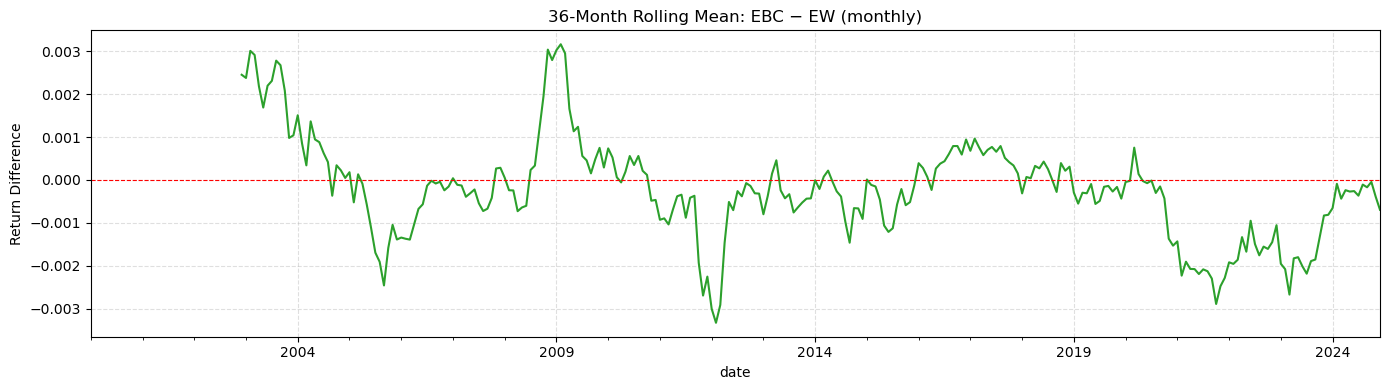

In [8]:
# ── EBC vs EW: are they actually the same portfolio? ──
comp = pd.DataFrame({
    "EBC": full_merged_df["EBC"],
    "EW":  full_merged_df["EW"]
})
comp = comp['2000':]
if isinstance(comp.index, pd.PeriodIndex):
    comp.index = comp.index.to_timestamp()
comp = comp.dropna()

corr = comp["EBC"].corr(comp["EW"])
diff = (comp["EBC"] - comp["EW"])

print(f"Correlation (EBC vs EW)       : {corr:.6f}")
print(f"Mean monthly return difference       : {diff.mean()*100:.4f}%  ({diff.mean()*1200:.2f}% annualized)")
print(f"Std of monthly return difference     : {diff.std()*100:.4f}%")
print(f"Max monthly divergence               : {diff.abs().max()*100:.4f}%")
print(f"EBC annualized mean return    : {comp['EBC'].mean()*12:.4%}")
print(f"EW  annualized mean return    : {comp['EW'].mean()*12:.4%}")

# Plot the return difference over time (full sample)
diff.rolling(36).mean().plot(figsize=(14,4), linewidth=1.5, color="tab:green")
plt.axhline(0, color="red", linestyle="--", linewidth=0.8)
plt.title("36-Month Rolling Mean: EBC − EW (monthly)")
plt.ylabel("Return Difference")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

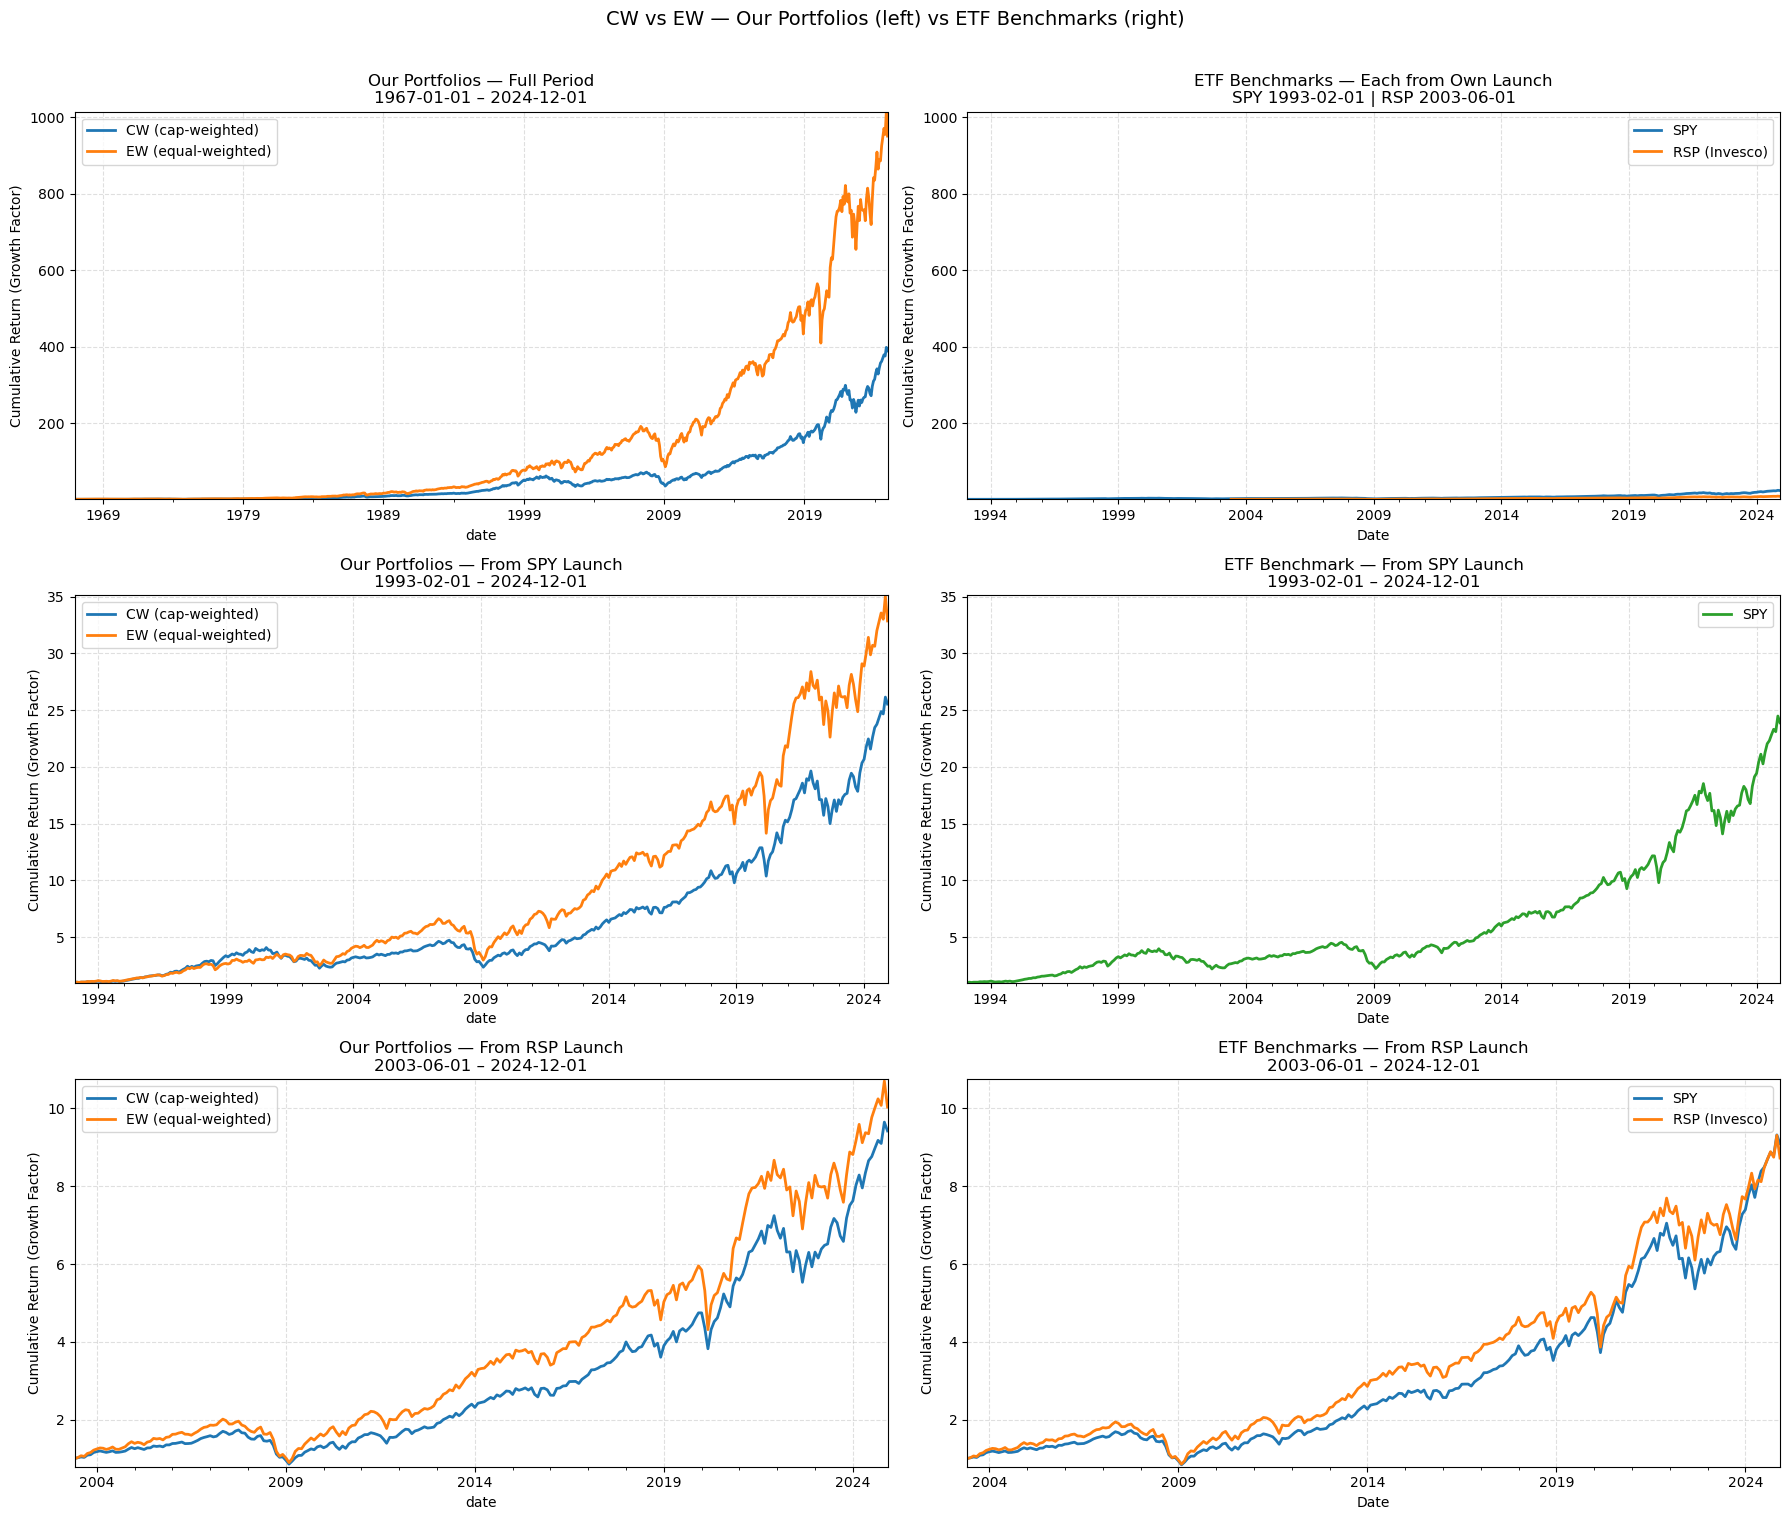


── Annualized Mean Return (raw) ──
  CW (ours, full)  : 11.49%
  EW (ours, full)  : 13.43%
  CW (ours, 1993+) : 11.31%
  EW (ours, 1993+) : 12.40%
  SPY  (1993+)     : 11.09%
  CW (ours, 2003+) : 11.50%
  EW (ours, 2003+) : 12.18%
  SPY  (2003+)     : 11.34%
  RSP  (2003+)     : 11.50%


In [9]:
import yfinance as yf

# ── Download ETF data ──
spy_prices = yf.download("SPY", start="1993-01-01", end="2025-01-01", progress=False, auto_adjust=True)["Close"].squeeze()
rsp_prices = yf.download("RSP", start="2003-01-01", end="2025-01-01", progress=False, auto_adjust=True)["Close"].squeeze()

spy_ret = spy_prices.resample("ME").last().pct_change().dropna()
rsp_ret = rsp_prices.resample("ME").last().pct_change().dropna()
spy_ret.index = spy_ret.index.to_period("M").to_timestamp(how="start")
rsp_ret.index = rsp_ret.index.to_period("M").to_timestamp(how="start")

# ── Our raw portfolios ──
our_data = full_merged_df[["CW", "EW"]].copy()
if isinstance(our_data.index, pd.PeriodIndex):
    our_data.index = our_data.index.to_timestamp(how="start")

spy_start = spy_ret.index.min()   # ~Jan 1993
rsp_start = rsp_ret.index.min()   # ~Apr 2003

# ── Helper: compute geometric cumulative returns ──
def cum_geo(df):
    return (1 + df).cumprod()

# ── 3 rows × 2 cols: left = our portfolios, right = ETFs, same y-scale per row ──
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

# ── Row 1: Full period ──
ours_full = cum_geo(our_data)
etf_full  = pd.concat([
    cum_geo(spy_ret).rename("SPY"),
    cum_geo(rsp_ret).rename("RSP (Invesco)")
], axis=1)

ours_full.plot(ax=axes[0, 0], linewidth=2)
axes[0, 0].set_title(f"Our Portfolios — Full Period\n{our_data.index.min().date()} – {our_data.index.max().date()}")
axes[0, 0].set_ylabel("Cumulative Return (Growth Factor)")
axes[0, 0].legend(["CW (cap-weighted)", "EW (equal-weighted)"])
axes[0, 0].grid(True, linestyle="--", alpha=0.4)

etf_full.plot(ax=axes[0, 1], linewidth=2)
axes[0, 1].set_title(f"ETF Benchmarks — Each from Own Launch\nSPY {spy_start.date()} | RSP {rsp_start.date()}")
axes[0, 1].set_ylabel("Cumulative Return (Growth Factor)")
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle="--", alpha=0.4)

ymin1 = min(ours_full.min().min(), etf_full.min().min())
ymax1 = max(ours_full.max().max(), etf_full.max().max())
for ax in axes[0]:
    ax.set_ylim(ymin1 - 0.05, ymax1 + 0.05)

# ── Row 2: From SPY launch (~1993) ──
ours_spy = cum_geo(our_data.loc[spy_start:])
etf_spy  = cum_geo(spy_ret.loc[spy_start:]).rename("SPY")

ours_spy.plot(ax=axes[1, 0], linewidth=2)
axes[1, 0].set_title(f"Our Portfolios — From SPY Launch\n{spy_start.date()} – {our_data.index.max().date()}")
axes[1, 0].set_ylabel("Cumulative Return (Growth Factor)")
axes[1, 0].legend(["CW (cap-weighted)", "EW (equal-weighted)"])
axes[1, 0].grid(True, linestyle="--", alpha=0.4)

etf_spy.plot(ax=axes[1, 1], linewidth=2, color="tab:green")
axes[1, 1].set_title(f"ETF Benchmark — From SPY Launch\n{spy_start.date()} – {spy_ret.index.max().date()}")
axes[1, 1].set_ylabel("Cumulative Return (Growth Factor)")
axes[1, 1].legend(["SPY"])
axes[1, 1].grid(True, linestyle="--", alpha=0.4)

ymin2 = min(ours_spy.min().min(), etf_spy.min())
ymax2 = max(ours_spy.max().max(), etf_spy.max())
for ax in axes[1]:
    ax.set_ylim(ymin2 - 0.05, ymax2 + 0.05)

# ── Row 3: From RSP launch (~2003) ──
ours_rsp = cum_geo(our_data.loc[rsp_start:])
etf_rsp  = pd.concat([
    cum_geo(spy_ret.loc[rsp_start:]).rename("SPY"),
    cum_geo(rsp_ret.loc[rsp_start:]).rename("RSP (Invesco)")
], axis=1)

ours_rsp.plot(ax=axes[2, 0], linewidth=2)
axes[2, 0].set_title(f"Our Portfolios — From RSP Launch\n{rsp_start.date()} – {our_data.index.max().date()}")
axes[2, 0].set_ylabel("Cumulative Return (Growth Factor)")
axes[2, 0].legend(["CW (cap-weighted)", "EW (equal-weighted)"])
axes[2, 0].grid(True, linestyle="--", alpha=0.4)

etf_rsp.plot(ax=axes[2, 1], linewidth=2)
axes[2, 1].set_title(f"ETF Benchmarks — From RSP Launch\n{rsp_start.date()} – {rsp_ret.index.max().date()}")
axes[2, 1].set_ylabel("Cumulative Return (Growth Factor)")
axes[2, 1].legend()
axes[2, 1].grid(True, linestyle="--", alpha=0.4)

ymin3 = min(ours_rsp.min().min(), etf_rsp.min().min())
ymax3 = max(ours_rsp.max().max(), etf_rsp.max().max())
for ax in axes[2]:
    ax.set_ylim(ymin3 - 0.05, ymax3 + 0.05)

plt.suptitle("CW vs EW — Our Portfolios (left) vs ETF Benchmarks (right)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Summary stats ──
print("\n── Annualized Mean Return (raw) ──")
print(f"  CW (ours, full)  : {our_data['CW'].mean()*12:.2%}")
print(f"  EW (ours, full)  : {our_data['EW'].mean()*12:.2%}")
print(f"  CW (ours, 1993+) : {our_data.loc[spy_start:,'CW'].mean()*12:.2%}")
print(f"  EW (ours, 1993+) : {our_data.loc[spy_start:,'EW'].mean()*12:.2%}")
print(f"  SPY  (1993+)     : {spy_ret.mean()*12:.2%}")
print(f"  CW (ours, 2003+) : {our_data.loc[rsp_start:,'CW'].mean()*12:.2%}")
print(f"  EW (ours, 2003+) : {our_data.loc[rsp_start:,'EW'].mean()*12:.2%}")
print(f"  SPY  (2003+)     : {spy_ret.loc[rsp_start:].mean()*12:.2%}")
print(f"  RSP  (2003+)     : {rsp_ret.mean()*12:.2%}")

# <span style="color:red"> Get rolling betas for the two focus portfolios EBC and CW - EBC </span>

#### create factor returns

In [10]:
ebc = ebc.to_frame(name="EBC")
cw_ebc = cw_ebc.to_frame(name="CW-EBC")

# Convert to timestamp to match asset_returns index
ebc.index = ebc.index.to_timestamp()
cw_ebc.index = cw_ebc.index.to_timestamp()

factor_returns = pd.concat([ebc, cw_ebc], axis=1).dropna()

#### get asset returns (raw, no RF subtraction)

In [11]:
asset_returns, caps_df, ff_factors = fmb_pipe.load_monthly_inputs(DATA_RAW_DIR, excess=False)

#### compute rolling betas for EBc and CW-EBC

In [12]:
betas_ebc = fmb_betas.compute_rolling_betas(asset_returns, ebc, rolling_window=36, min_obs=10)
betas_cw_ebc = fmb_betas.compute_rolling_betas(asset_returns, cw_ebc, rolling_window=36, min_obs=10)

Estimating rolling betas: 100%|██████████| 660/660 [00:22<00:00, 28.87it/s]


=== Beta Coverage ===
EBC betas   : (660, 1955)  |  date range: 1970-01-01 → 2024-12-01
CW-EBC betas: (660, 1955)  |  date range: 1970-01-01 → 2024-12-01

=== Average non-NaN assets per period (first 5 / last 5) ===
EBC betas:
date
1970-01-01    405
1970-02-01    406
1970-03-01    406
1970-04-01    406
1970-05-01    403
2024-08-01    445
2024-09-01    447
2024-10-01    445
2024-11-01    444
2024-12-01    445
CW-EBC betas:
date
1970-01-01    405
1970-02-01    406
1970-03-01    406
1970-04-01    406
1970-05-01    403
2024-08-01    445
2024-09-01    447
2024-10-01    445
2024-11-01    444
2024-12-01    445

=== Cross-sectional distribution (all dates stacked) ===
          EBC beta  CW-EBC beta
count  278445.0000  278445.0000
mean        1.1136      -0.3264
std         0.5163       1.9140
min        -0.0461      -6.8890
25%         0.7658      -1.3835
50%         1.0743      -0.3646
75%         1.4038       0.7735
max         3.0649       5.3911

=== Cross-correlation between mean EBC bet

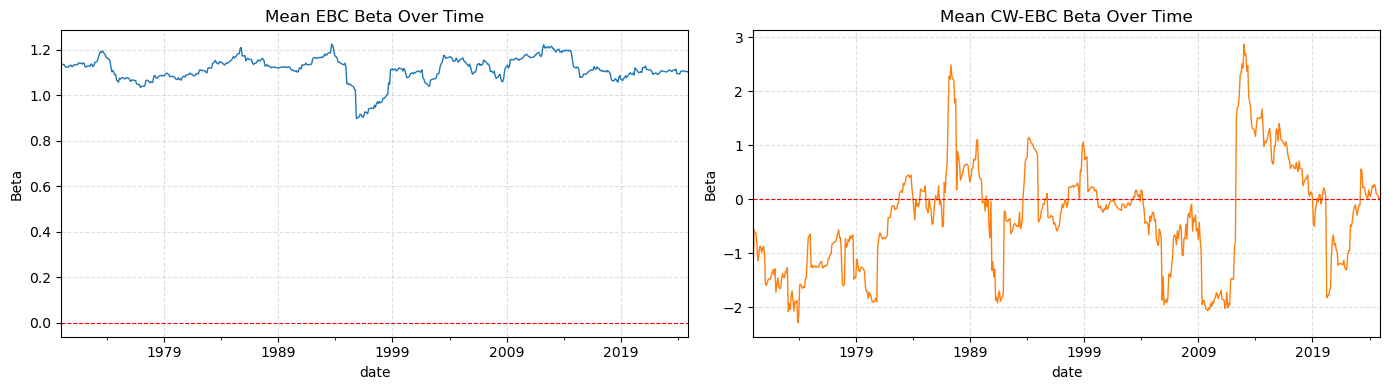

In [13]:
# ── Basic beta sanity checks ──

print("=== Beta Coverage ===")
print(f"EBC betas   : {betas_ebc.shape}  |  date range: {betas_ebc.index.min().date()} → {betas_ebc.index.max().date()}")
print(f"CW-EBC betas: {betas_cw_ebc.shape}  |  date range: {betas_cw_ebc.index.min().date()} → {betas_cw_ebc.index.max().date()}")

print("\n=== Average non-NaN assets per period (first 5 / last 5) ===")
ebc_coverage   = betas_ebc.notna().sum(axis=1)
cwebc_coverage = betas_cw_ebc.notna().sum(axis=1)
print("EBC betas:")
print(pd.concat([ebc_coverage.head(), ebc_coverage.tail()]).to_string())
print("CW-EBC betas:")
print(pd.concat([cwebc_coverage.head(), cwebc_coverage.tail()]).to_string())

print("\n=== Cross-sectional distribution (all dates stacked) ===")
ebc_flat   = betas_ebc.stack(future_stack=True).dropna()
cwebc_flat = betas_cw_ebc.stack(future_stack=True).dropna()
print(pd.DataFrame({
    "EBC beta": ebc_flat.describe(),
    "CW-EBC beta": cwebc_flat.describe()
}).round(4))

print("\n=== Cross-correlation between mean EBC beta and mean CW-EBC beta (should be low) ===")
mean_betas = pd.DataFrame({
    "mean_EBC": betas_ebc.mean(axis=1),
    "mean_CW_EBC": betas_cw_ebc.mean(axis=1)
}).dropna()
print(mean_betas.corr().round(3))

# ── Quick time-series plot of cross-sectional mean betas ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
mean_betas["mean_EBC"].plot(ax=axes[0], linewidth=1)
axes[0].set_title("Mean EBC Beta Over Time")
axes[0].set_ylabel("Beta")
axes[0].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[0].grid(True, linestyle="--", alpha=0.4)

mean_betas["mean_CW_EBC"].plot(ax=axes[1], linewidth=1, color="tab:orange")
axes[1].set_title("Mean CW-EBC Beta Over Time")
axes[1].set_ylabel("Beta")
axes[1].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# <span style="color:red"> Cap Weighted Portfolio Plots --> Run full factor pipeline --> Two factor regressions FMB </span>

In [14]:
start_date = "1999-10-01"

## Filter all returns to match start date

In [15]:
asset_returns_trimmed = asset_returns.loc[start_date:]
caps_df_trimmed = caps_df.loc[start_date:]
factor_returns_trimmed = factor_returns.loc[start_date:]
betas_ebc_trimmed = betas_ebc.loc[start_date:]
betas_cw_ebc_trimmed = betas_cw_ebc.loc[start_date:]

In [16]:
n_q1, n_q2 = 1,3

In [17]:
cw_results = fmb_pipe.run_full_factor_pipeline(
    beta_EBC_df = betas_ebc_trimmed,
    beta_CW_EBC_df=betas_cw_ebc_trimmed,
    returns_df=asset_returns_trimmed,
    caps_df = caps_df_trimmed,
    EBC_returns_df=factor_returns_trimmed["EBC"],
    Cap_EBC_returns_df=factor_returns_trimmed["CW-EBC"],
    cap_weights=True,
    n_q1 = n_q1,
    n_q2 = n_q2,
    frequency = 'monthly',
    formation_frequency='quarterly',
    min_assets_per_cell=3,
    f1_name="EBC",
    f2_name="CW-EBC"
)

cw_results["mean_grid"]*12

Q1 buckets:   0%|          | 0/1 [00:00<?, ?it/s]

,1,2,3
1,0.091589,0.092197,0.109428


In [18]:
rename_map =  {
    "Q1_Q1": "High Pref",
    "Q1_Q2": "Mid Pref",
    "Q1_Q3": "Low Pref"
}
# Save pre-rename copy for true geometric mean computation (needs Q1_Q1 style column names)
cw_portrets_raw = cw_results['portrets_wide'].copy()
cw_results['portrets_wide'] = cw_results['portrets_wide'].rename(columns=rename_map)

In [19]:
full_merged_df.index = full_merged_df.index.to_timestamp(how="start")

In [20]:

cw_complete_df = full_merged_df.join(
    cw_results['portrets_wide'],
    how="inner"
)

selected_columns = ["CW","High Pref","Mid Pref","Low Pref"]

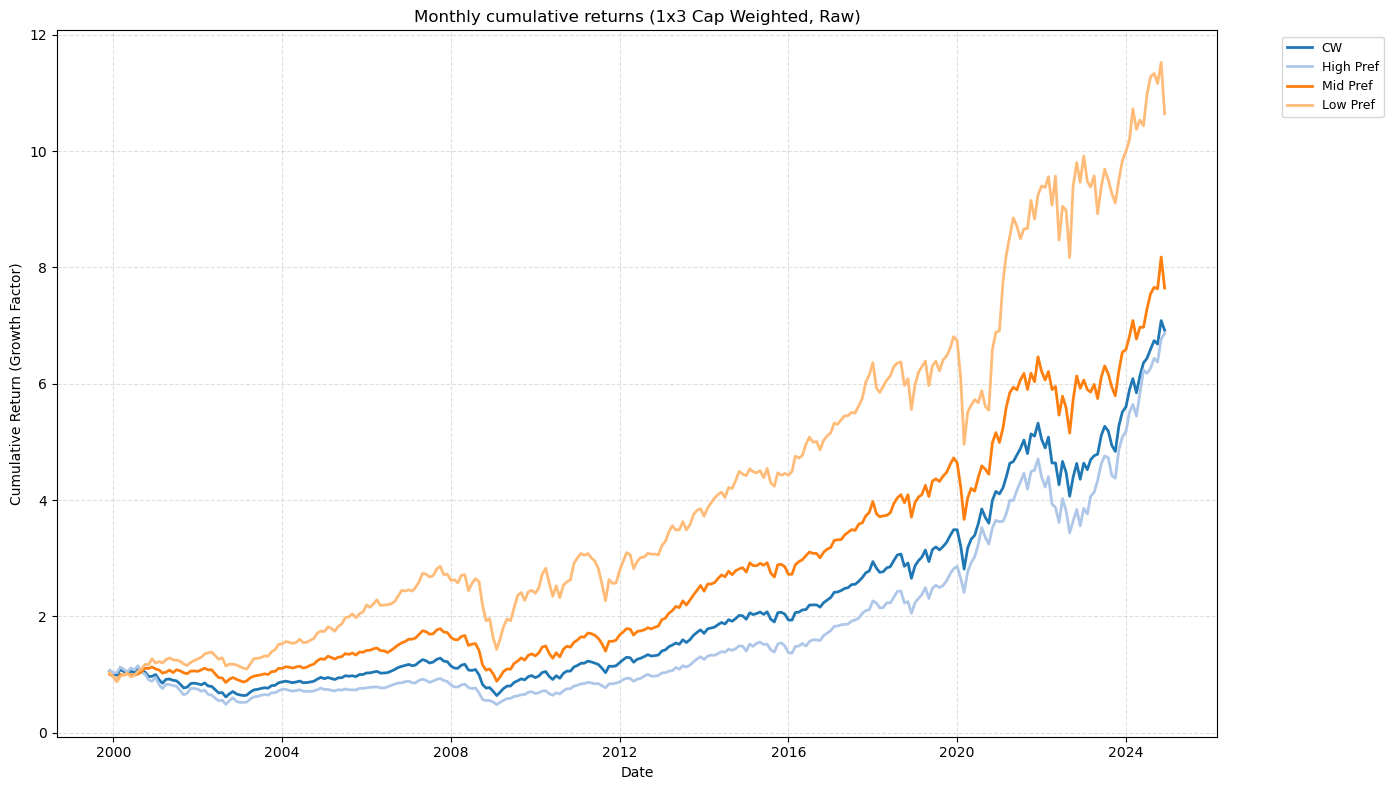

In [21]:

fmb_plots.plot_cum_returns(cw_complete_df[selected_columns], title=f"Monthly cumulative returns ({n_q1}x{n_q2} Cap Weighted, Raw)", log=False)

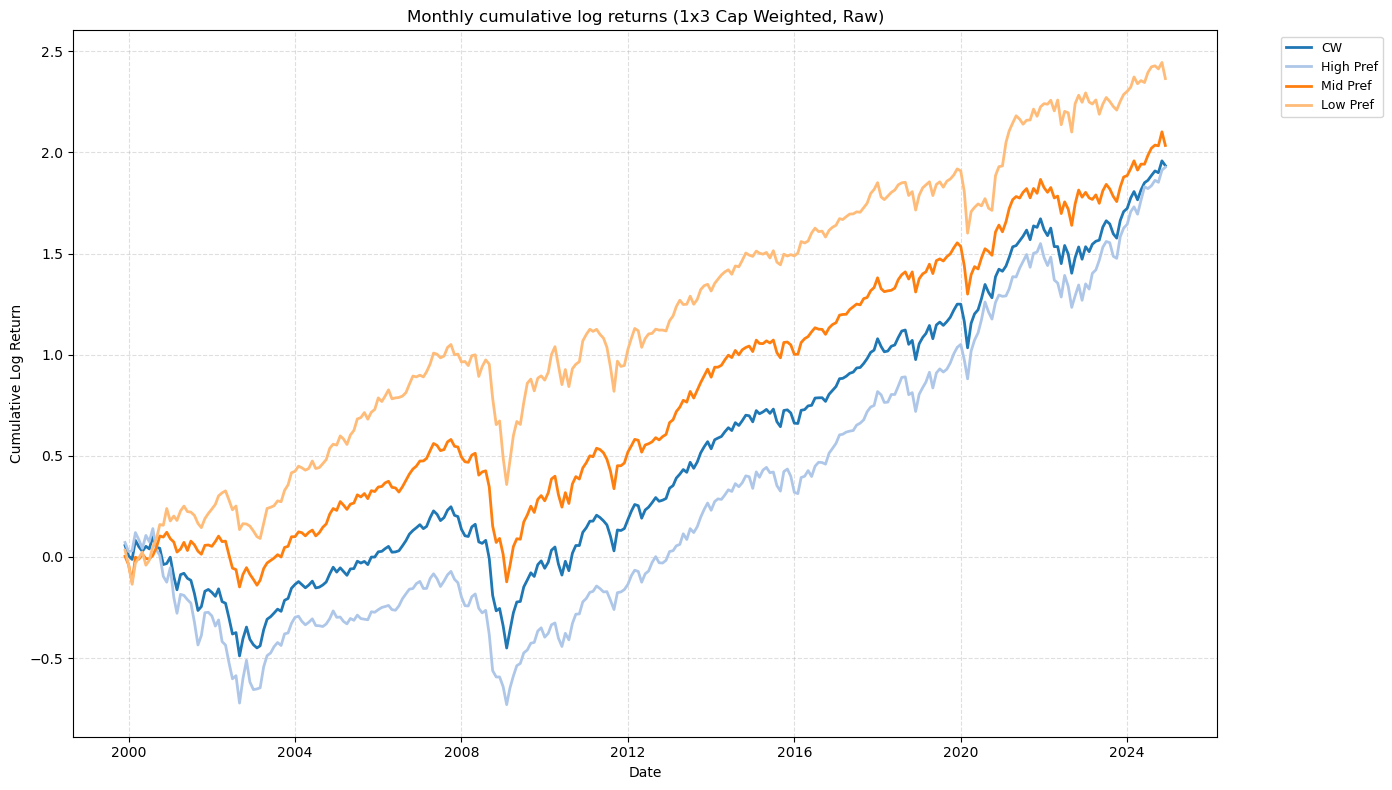

In [22]:
fmb_plots.plot_cum_returns(cw_complete_df[selected_columns], title = f"Monthly cumulative log returns ({n_q1}x{n_q2} Cap Weighted, Raw)")

In [23]:
period = start_date[:4] + '_2024'
save_dir = DATA_PROCESSED_DIR / 'monthly'

In [24]:
monthly_cw_quantile_returns = cw_complete_df[selected_columns]
monthly_cw_quantile_returns.to_csv(save_dir / f"monthly_{period}_cw_quantile_returns_{n_q1}x{n_q2}.csv")

In [25]:
# Arithmetic mean grid (annualized as mean × 12)
#fmb_plots.plot_mean_grid_new(cw_results["mean_grid"], annualize=True, cw=True, geometric=False)

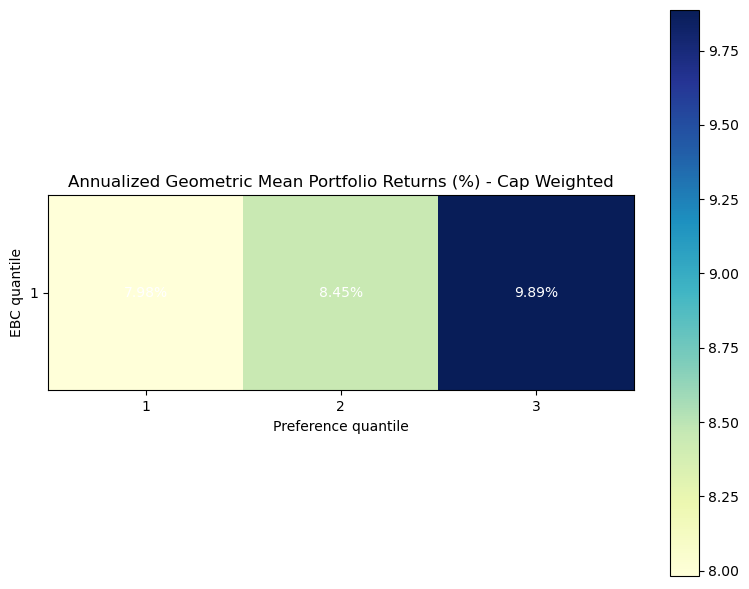

In [26]:
# True geometric mean grid (annualized as (1+geo_monthly)^12 − 1)
cw_actual_mean_grid = fmb_plots.plot_mean_grid_new(
    cw_results["mean_grid"], annualize=True, cw=True, geometric=True,
    portrets_wide=cw_portrets_raw
)

In [27]:
# ── Benchmark: annualized geometric mean returns over the analysis period ──
cw_geo = np.expm1(np.log1p(cw_complete_df['CW']).mean())
cw_ann = (1 + cw_geo) ** 12 - 1
print(f"Annualized Geometric Mean Return ({start_date[:4]}–2024)")
print(f"  CW (ours) : {cw_ann:.2%}")
try:
    spy_geo = np.expm1(np.log1p(spy_ret.loc[start_date:]).mean())
    spy_ann = (1 + spy_geo) ** 12 - 1
    print(f"  SPY       : {spy_ann:.2%}")
except Exception:
    print("  SPY       : (run ETF cell first)")

Annualized Geometric Mean Return (1999–2024)
  CW (ours) : 8.02%
  SPY       : 8.11%


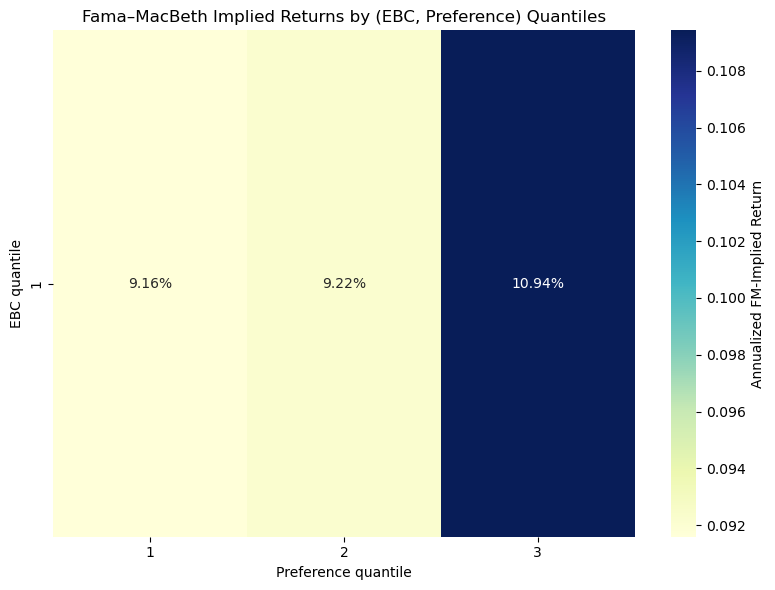

In [28]:
cw_implied_mean_grid = fmb_plots.plot_expected_return_grid(cw_results["pricing"], cw_results["fm_table"], n_q1, n_q2)

## turnover

In [29]:
# ── Portfolio Turnover (Cap Weighted) ─────────────────────────────────────
# Turnover = % of stocks that left each cell at each quarterly rebalancing.
# Stock membership is determined by beta sorts (identical for CW and EW).

members_cw = cw_results["members"].copy()
m = members_cw.reset_index()

# First date of each quarter = rebalancing snapshot
m['period'] = m['date'].dt.to_period('Q')
first_date_per_period = m.groupby('period')['date'].min()
m_first = m[m['date'].isin(first_date_per_period.values)]

portfolio_names = {
    (1,1): "High Preference",
    (1,2): "Mid Preference",
    (1,3): "Low Preference"
    
}

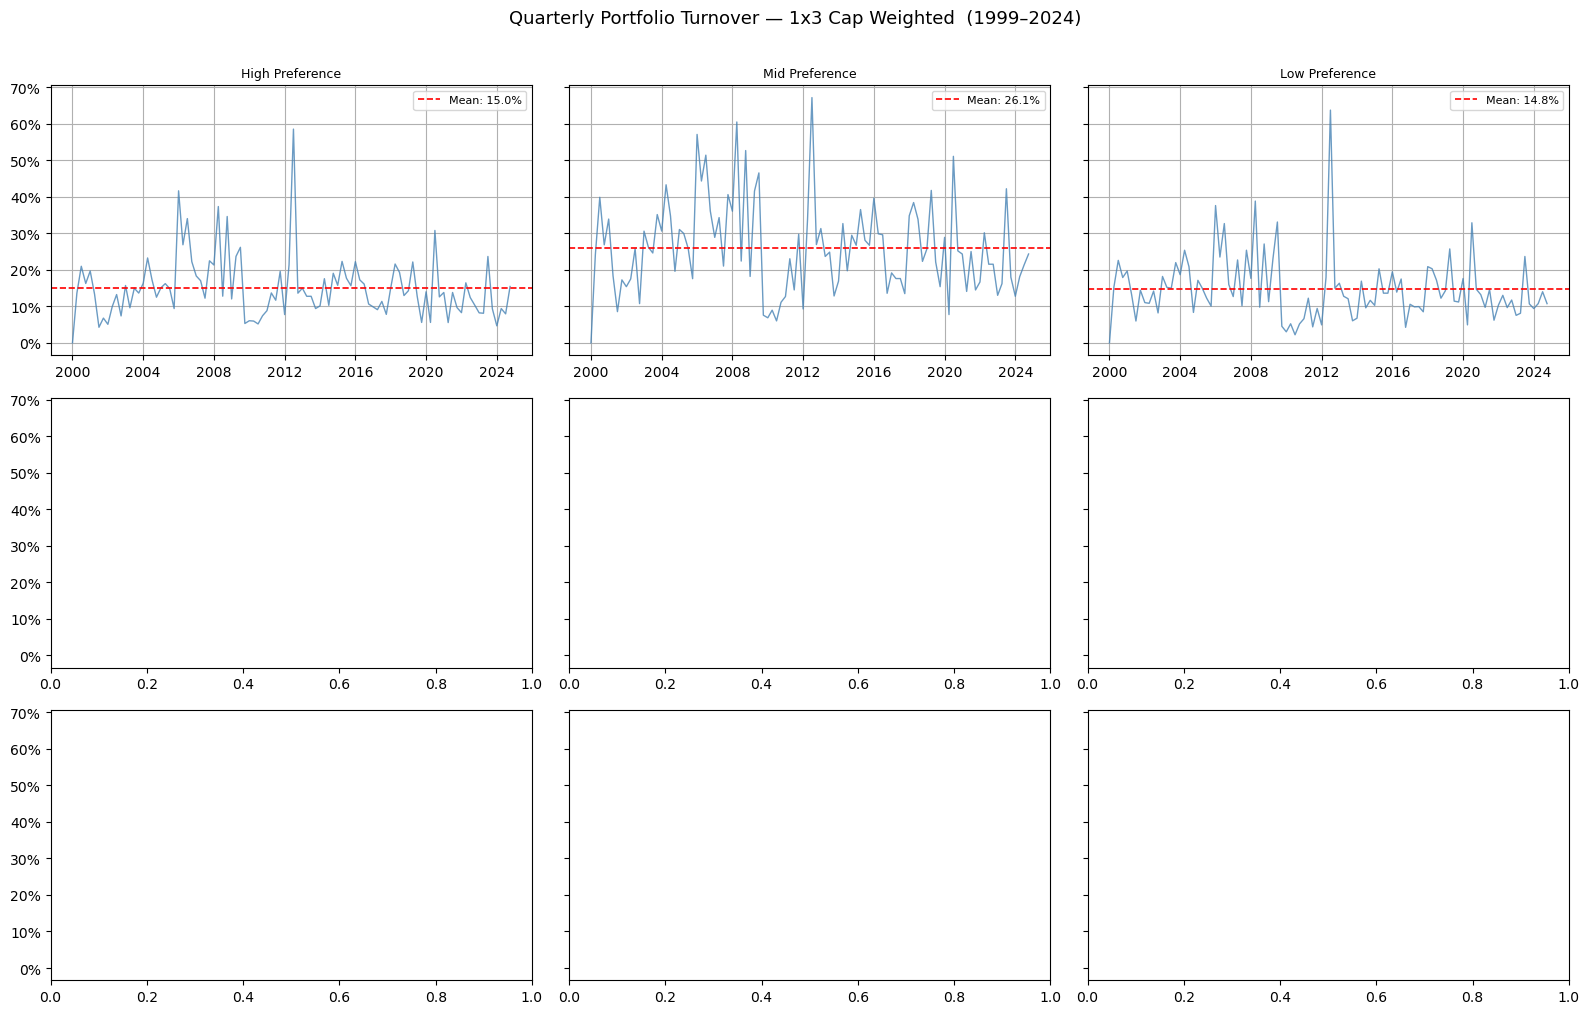

In [30]:
turnover_dict_cw = {}
for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        cell_data = m_first[(m_first['q1'] == q1) & (m_first['q2'] == q2)]
        by_period = cell_data.groupby('period')['ticker'].apply(set)
        turnovers, dates_out = [], []
        prev_set = None
        for period_key, tickers in by_period.items():
            if prev_set is not None:
                left = prev_set - tickers
                turnovers.append(len(left) / len(prev_set) if prev_set else np.nan)
                dates_out.append(period_key.to_timestamp())
            prev_set = tickers
        turnover_dict_cw[portfolio_names[(q1, q2)]] = pd.Series(turnovers, index=dates_out)

turnover_cw = pd.DataFrame(turnover_dict_cw)

# ── Plot: 3x3 grid ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharey=True)
for ax, col in zip(axes.flatten(), turnover_cw.columns):
    avg = turnover_cw[col].mean()
    ax.plot(turnover_cw.index, turnover_cw[col], color='steelblue', linewidth=1, alpha=0.8)
    ax.axhline(avg, color='red', linestyle='--', linewidth=1.2, label=f"Mean: {avg:.1%}")
    ax.set_title(col, fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.legend(fontsize=8)
    ax.grid(True)
plt.suptitle(
    f"Quarterly Portfolio Turnover — {n_q1}x{n_q2} Cap Weighted  ({period.replace('_', chr(8211))})",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

In [31]:
# ── Average turnover summary table ─────────────────────────────────────────
avg_to_cw = pd.DataFrame({
    "Avg Quarterly Turnover": turnover_cw.mean(),
    "Annualized Turnover":    turnover_cw.mean() * 4,
}).round(4)
print("Average Turnover by Portfolio Cell (Cap Weighted):")
display(avg_to_cw)

Average Turnover by Portfolio Cell (Cap Weighted):


,Avg Quarterly Turnover,Annualized Turnover
High Preference,0.1503,0.6012
Mid Preference,0.2607,1.0427
Low Preference,0.1477,0.5908


In [32]:
# ── Save ────────────────────────────────────────────────────────────────────
turnover_cw.to_csv(save_dir / f"monthly_{period}_turnover_{n_q1}x{n_q2}.csv")
print(f"Saved: monthly_{period}_cw_turnover_{n_q1}x{n_q2}.csv")

Saved: monthly_1999_2024_cw_turnover_1x3.csv


# <span style="color:red"> Equal Weighted Portfolio Plots --> Run full factor pipeline --> Two factor regressions FMB </span>

In [33]:
ew_results = fmb_pipe.run_full_factor_pipeline(
    beta_EBC_df = betas_ebc_trimmed,
    beta_CW_EBC_df=betas_cw_ebc_trimmed,
    returns_df=asset_returns_trimmed,
    caps_df = caps_df_trimmed,
    EBC_returns_df=factor_returns_trimmed["EBC"],
    Cap_EBC_returns_df=factor_returns_trimmed["CW-EBC"],
    cap_weights=False,
    n_q1 = n_q1,
    n_q2 = n_q2,
    frequency = 'monthly',
    formation_frequency='quarterly',
    min_assets_per_cell=3,
    f1_name="EBC",
    f2_name="CW-EBC"
)

ew_results["mean_grid"]*12

Q1 buckets:   0%|          | 0/1 [00:00<?, ?it/s]

,1,2,3
1,0.106474,0.117427,0.123457


In [34]:
# Save pre-rename copy for true geometric mean computation (needs Q1_Q1 style column names)
ew_portrets_raw = ew_results['portrets_wide'].copy()
ew_results['portrets_wide'] = ew_results['portrets_wide'].rename(columns=rename_map)

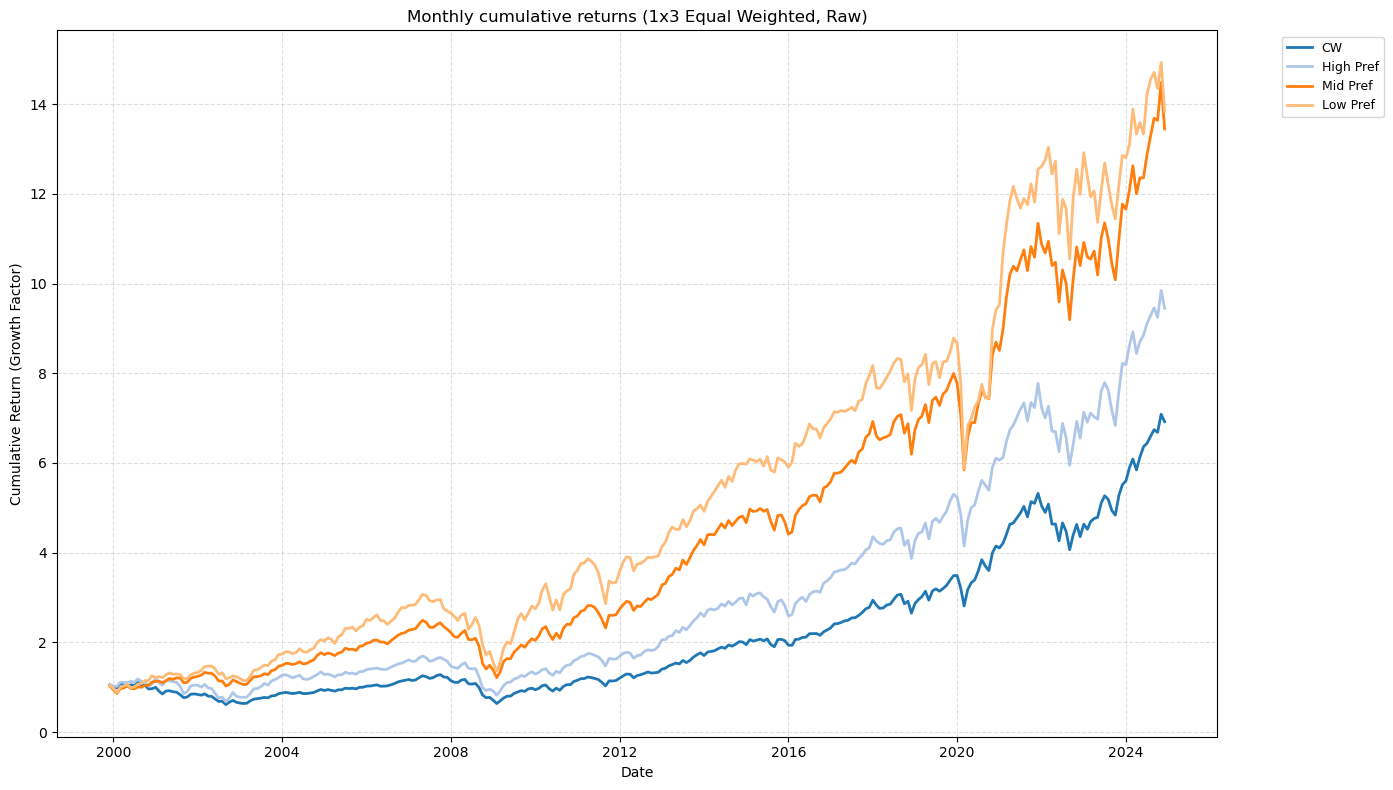

In [35]:
ew_complete_df = full_merged_df.join(
    ew_results['portrets_wide'],
    how="inner"
)

fmb_plots.plot_cum_returns(ew_complete_df[selected_columns],
                                title=f"Monthly cumulative returns ({n_q1}x{n_q2} Equal Weighted, Raw)", log=False)

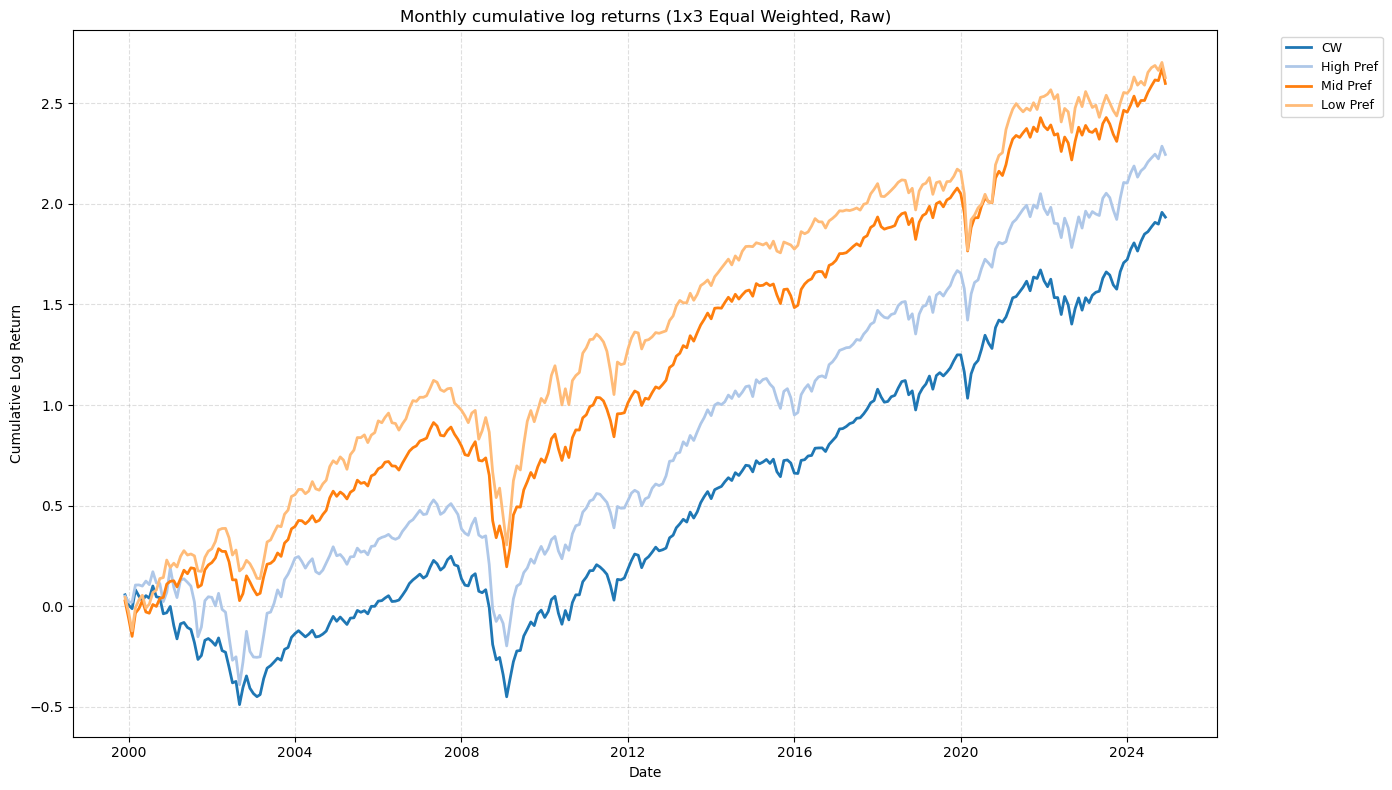

In [36]:
fmb_plots.plot_cum_returns(ew_complete_df[selected_columns],
                                title=f"Monthly cumulative log returns ({n_q1}x{n_q2} Equal Weighted, Raw)",log = True)

In [37]:
monthly_ew_quantile_returns = ew_complete_df[selected_columns]

In [38]:
monthly_ew_quantile_returns.to_csv(save_dir / f"monthly_{period}_ew_quantile_returns_{n_q1}x{n_q2}.csv")

In [39]:
# Arithmetic mean grid (annualized as mean × 12)
#fmb_plots.plot_mean_grid_new(ew_results["mean_grid"], annualize=True, frequency='monthly', cw=False, geometric=False)

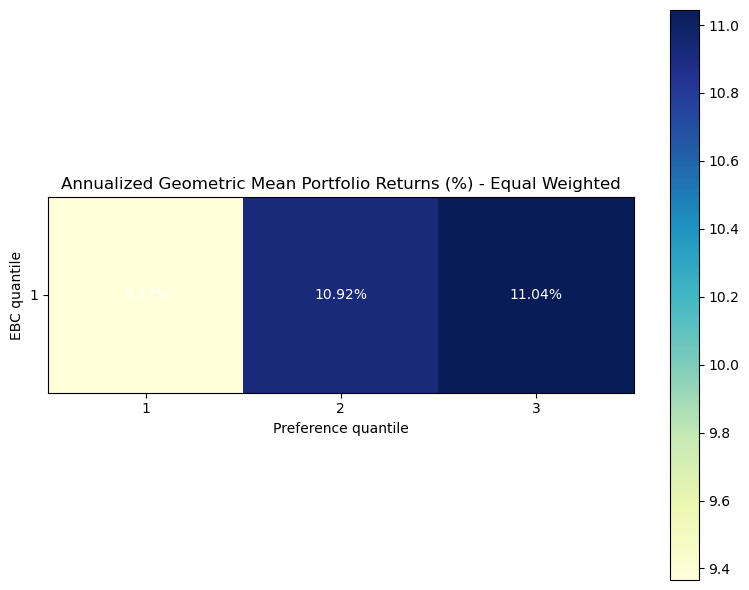

In [40]:
# True geometric mean grid (annualized as (1+geo_monthly)^12 − 1)
ew_actual_mean_grid = fmb_plots.plot_mean_grid_new(
    ew_results["mean_grid"], annualize=True, frequency='monthly', cw=False, geometric=True,
    portrets_wide=ew_portrets_raw
)

In [41]:
# ── Benchmark: annualized geometric mean returns over the analysis period ──
cw_geo = np.expm1(np.log1p(cw_complete_df['CW']).mean())
cw_ann = (1 + cw_geo) ** 12 - 1
print(f"Annualized Geometric Mean Return ({start_date[:4]}–2024)")
print(f"  CW (ours) : {cw_ann:.2%}")
try:
    spy_geo = np.expm1(np.log1p(spy_ret.loc[start_date:]).mean())
    spy_ann = (1 + spy_geo) ** 12 - 1
    print(f"  SPY       : {spy_ann:.2%}")
except Exception:
    print("  SPY       : (run ETF cell first)")

Annualized Geometric Mean Return (1999–2024)
  CW (ours) : 8.02%
  SPY       : 8.11%


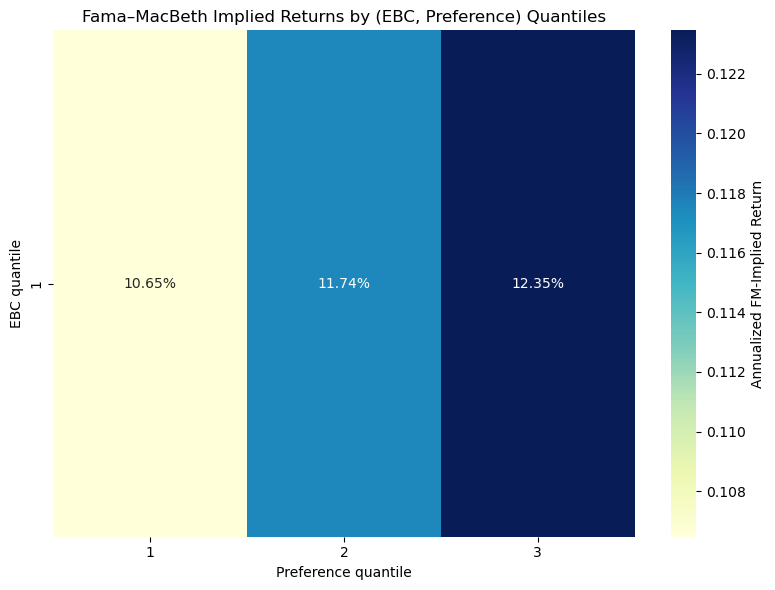

In [42]:
ew_implied_mean_grid = fmb_plots.plot_expected_return_grid(ew_results["pricing"], ew_results["fm_table"], n_q1, n_q2)

# <span style="color:red"> Transaction Costs — EW Quantile Portfolios </span>

**Formula (Invesco):** `TC = 2 × Turnover × 0.005`

| Term | Meaning |
|---|---|
| `Turnover` | Fraction of holdings that *exit* a cell at each quarterly rebalancing |
| `0.005` | One-way cost per dollar traded (50 bps: bid-ask spread + execution) |
| `× 2` | Round-trip: pay the spread to **sell** exiting stocks **and** to **buy** replacements |

Rebalancing is **quarterly**, so the cost is a one-time deduction applied in the **first month** of each new quarter. Non-rebalancing months are unaffected.

> To change the cost assumption, adjust `ONE_WAY_COST` below.

In [43]:
ONE_WAY_COST = 0.005  # bps per side — change here to update everything below

# ── Step 1: EW turnover (from member assignments) ─────────────────────────
# Turnover is identical for EW and CW since they share the same beta sorts / membership
members_ew = ew_results["members"].copy()
m_ew = members_ew.reset_index()
m_ew['period'] = m_ew['date'].dt.to_period('Q')
first_date_per_period_ew = m_ew.groupby('period')['date'].min()
m_ew_first = m_ew[m_ew['date'].isin(first_date_per_period_ew.values)]

portfolio_names_ew = {
    (1,1): "EBC_High_Pref_High", (1,2): "EBC_High_Pref_Mid", (1,3): "EBC_High_Pref_Low",
    (2,1): "EBC_Mid_Pref_High",  (2,2): "EBC_Mid_Pref_Mid",  (2,3): "EBC_Mid_Pref_Low",
    (3,1): "EBC_Low_Pref_High",  (3,2): "EBC_Low_Pref_Mid",  (3,3): "EBC_Low_Pref_Low",
}

turnover_dict_ew = {}
for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        cell_data = m_ew_first[(m_ew_first['q1'] == q1) & (m_ew_first['q2'] == q2)]
        by_period = cell_data.groupby('period')['ticker'].apply(set)
        turnovers, dates_out = [], []
        prev_set = None
        for period_key, tickers in by_period.items():
            if prev_set is not None:
                left = prev_set - tickers
                turnovers.append(len(left) / len(prev_set) if prev_set else np.nan)
                dates_out.append(period_key.to_timestamp())
            prev_set = tickers
        turnover_dict_ew[portfolio_names_ew[(q1, q2)]] = pd.Series(turnovers, index=dates_out)

turnover_ew = pd.DataFrame(turnover_dict_ew)
turnover_ew_q = turnover_ew.copy()
turnover_ew_q.index = pd.DatetimeIndex(turnover_ew_q.index).to_period('Q')

# ── Step 2: Helper — map quarterly TC to first monthly return of each quarter
def build_tc_monthly(gross_df, turnover_q_df, one_way_cost):
    monthly_quarters = gross_df.index.to_period('Q')
    first_month_of_quarter = {}
    for date, q in zip(gross_df.index, monthly_quarters):
        if q not in first_month_of_quarter:
            first_month_of_quarter[q] = date
    tc = pd.DataFrame(0.0, index=gross_df.index, columns=gross_df.columns)
    for col in turnover_q_df.columns:
        if col not in tc.columns:
            continue
        for q_period, to_val in turnover_q_df[col].items():
            if q_period in first_month_of_quarter and not np.isnan(to_val):
                tc.loc[first_month_of_quarter[q_period], col] = 2 * to_val * one_way_cost
    return tc

# ── Step 3: Apply TC to both EW and CW portfolios ─────────────────────────
ew_gross = ew_results['portrets_wide'].copy()
cw_gross = cw_results['portrets_wide'].copy()

ew_tc = build_tc_monthly(ew_gross, turnover_ew_q, ONE_WAY_COST)
cw_tc = build_tc_monthly(cw_gross, turnover_ew_q, ONE_WAY_COST)

ew_net = ew_gross - ew_tc
cw_net = cw_gross - cw_tc

print(f"One-way cost : {ONE_WAY_COST*10_000:.1f} bps  |  Round-trip per 100% turnover: {2*ONE_WAY_COST*100:.2f}%")
print(f"\nMean quarterly TC per EW portfolio (bps):")
print((ew_tc[ew_tc > 0].mean() * 10_000).round(2).to_string())

One-way cost : 50.0 bps  |  Round-trip per 100% turnover: 1.00%

Mean quarterly TC per EW portfolio (bps):
High Pref   NaN
Mid Pref    NaN
Low Pref    NaN


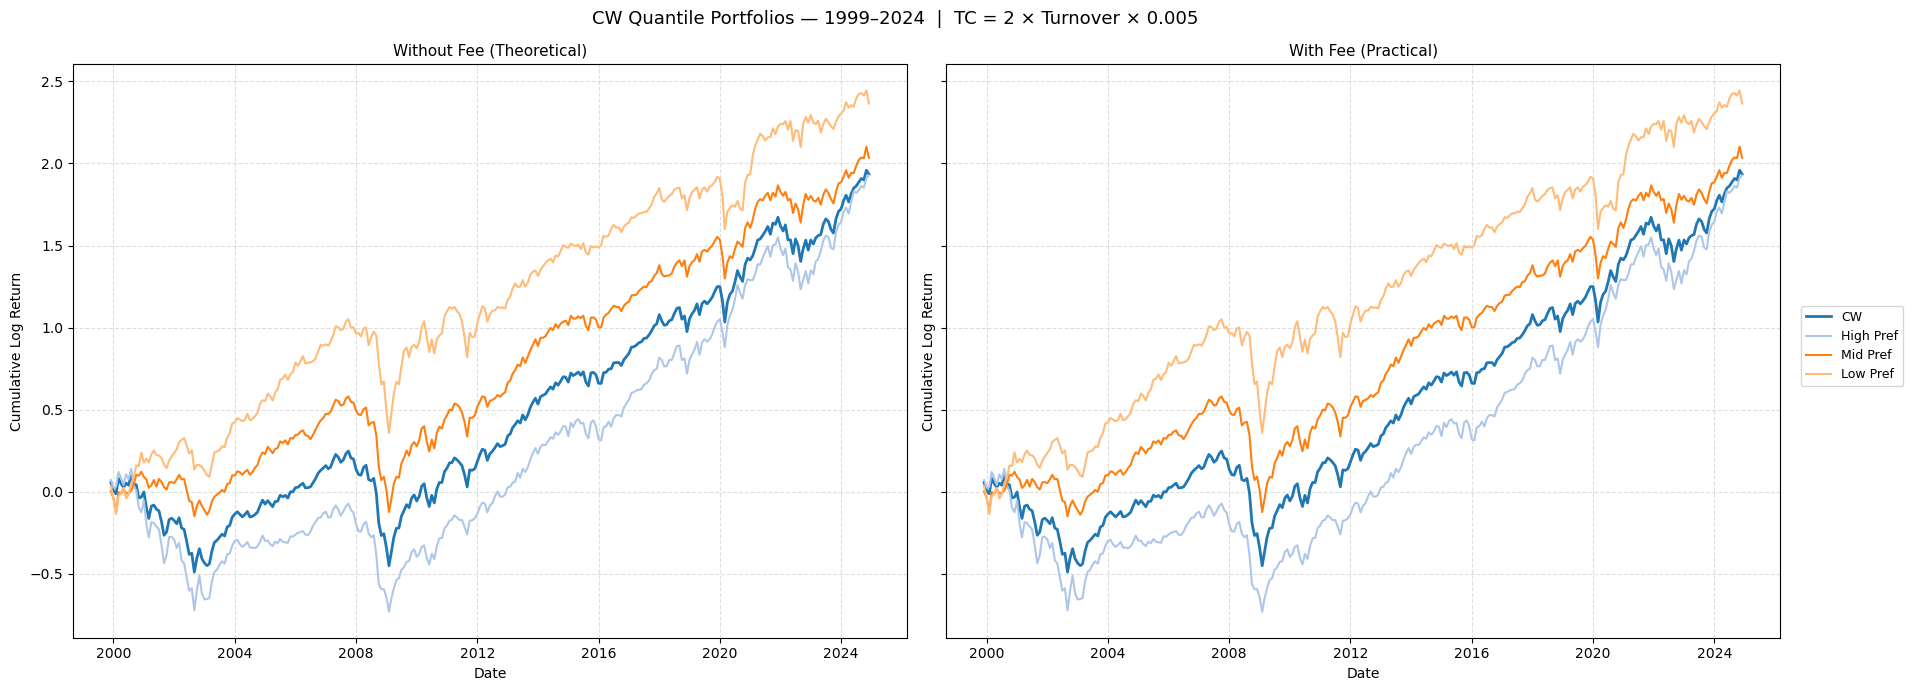

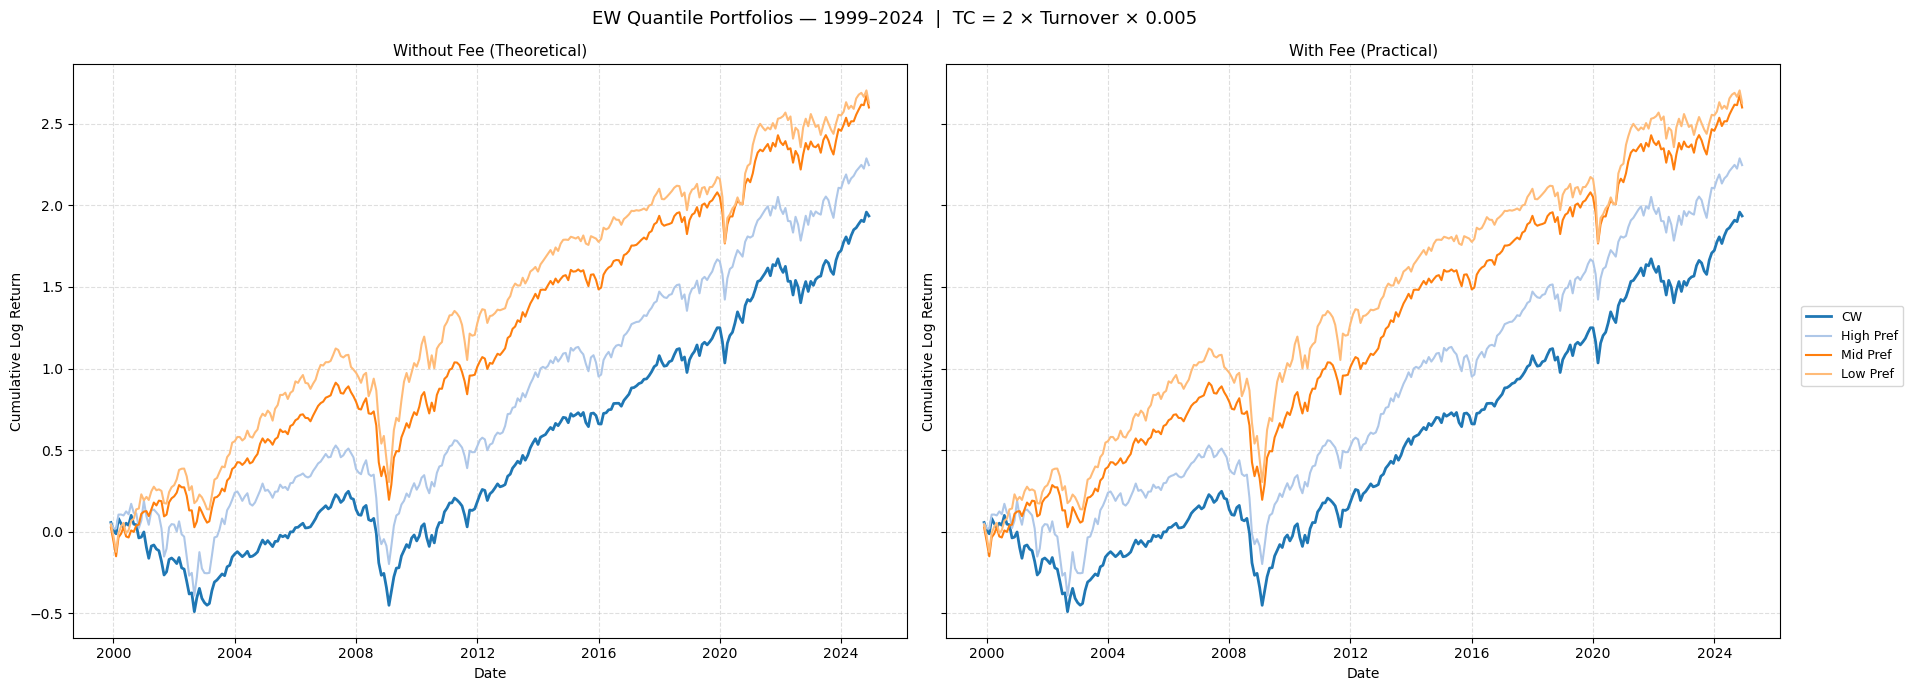

In [44]:
# ── Gross vs Net side-by-side (log cumulative returns) ────────────────────
# Left  = Without fee (theoretical)  |  Right = With fee (practical)

palette = plt.cm.tab20.colors
bench_color = palette[0]
port_colors = palette[1:10]

port_cols = list(ew_gross.columns)

bench = cw_complete_df['CW'].dropna()
bench_logcum = np.log1p(bench).cumsum()

def plot_gross_net_side_by_side(gross_df, net_df, bench_logcum, suptitle):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    for ax, df, subtitle in zip(axes,
                                [gross_df, net_df],
                                ["Without Fee (Theoretical)", "With Fee (Practical)"]):
        ax.plot(bench_logcum.index, bench_logcum.values,
                color=bench_color, linewidth=2, label='CW')
        for col, color in zip(port_cols, port_colors):
            lc = np.log1p(df[col].dropna()).cumsum()
            ax.plot(lc.index, lc.values, color=color, linewidth=1.5, label=col)
        ax.set_title(subtitle, fontsize=11)
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative Log Return")
        ax.grid(True, linestyle='--', alpha=0.4)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=1, fontsize=9,
               bbox_to_anchor=(1.0, 0.5), loc='center left')
    fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_gross_net_side_by_side(
    cw_gross, cw_net, bench_logcum,
    f"CW Quantile Portfolios — {period.replace('_','–')}  |  TC = 2 × Turnover × {ONE_WAY_COST}"
)

plot_gross_net_side_by_side(
    ew_gross, ew_net, bench_logcum,
    f"EW Quantile Portfolios — {period.replace('_','–')}  |  TC = 2 × Turnover × {ONE_WAY_COST}"
)

In [45]:
# ── Summary: Gross vs Net annualized geometric mean returns ───────────────
def tc_summary(gross_df, net_df, tc_df, label):
    rows = []
    for col in gross_df.columns:
        ann_gross = (1 + np.expm1(np.log1p(gross_df[col].dropna()).mean())) ** 12 - 1
        ann_net   = (1 + np.expm1(np.log1p(net_df[col].dropna()).mean())) ** 12 - 1
        avg_ann_tc = tc_df[col][tc_df[col] > 0].mean() * 4  # 4 quarters/year
        rows.append({
            "Portfolio": col.replace("EBC_", "").replace("_", " "),
            "Gross Ann.": f"{ann_gross:.2%}",
            "Net Ann.":   f"{ann_net:.2%}",
            "TC Drag (bps)": f"{(ann_gross - ann_net)*10_000:.1f}",
            "Avg Ann. TC (bps)": f"{avg_ann_tc*10_000:.1f}",
        })
    df = pd.DataFrame(rows).set_index("Portfolio")
    print(f"\n{'─'*60}")
    print(f"  {label}  |  {ONE_WAY_COST*10_000:.0f}bps/side  |  Formula: 2 × Turnover × {ONE_WAY_COST}")
    print(f"{'─'*60}")
    display(df)

tc_summary(ew_gross, ew_net, ew_tc, "EW Quantile Portfolios")
tc_summary(cw_gross, cw_net, cw_tc, "CW Quantile Portfolios")


────────────────────────────────────────────────────────────
  EW Quantile Portfolios  |  50bps/side  |  Formula: 2 × Turnover × 0.005
────────────────────────────────────────────────────────────


,Gross Ann.,Net Ann.,TC Drag (bps),Avg Ann. TC (bps)
Portfolio,,,,
High Pref,9.37%,9.37%,0.0,nan
Mid Pref,10.92%,10.92%,0.0,nan
Low Pref,11.04%,11.04%,0.0,nan



────────────────────────────────────────────────────────────
  CW Quantile Portfolios  |  50bps/side  |  Formula: 2 × Turnover × 0.005
────────────────────────────────────────────────────────────


,Gross Ann.,Net Ann.,TC Drag (bps),Avg Ann. TC (bps)
Portfolio,,,,
High Pref,7.98%,7.98%,0.0,nan
Mid Pref,8.45%,8.45%,0.0,nan
Low Pref,9.89%,9.89%,0.0,nan


# <span style="color:red"> Fitted GARCH </span>

In [46]:
from arch import arch_model


In [47]:
def fit_garch_model(returns):
    """
    Fit GARCH(1,1) with student t errors
    """

    returns = returns.dropna()

    # Scale to percentage
    returns_scaled = returns * 100

    am = arch_model(
        returns_scaled,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="t"
    )

    res = am.fit(disp="off")

    return res


In [48]:
cw_complete_df.columns

Index(['CW', 'EW', 'EBC', 'MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'MOM',
       'CW_RF', 'EW_RF', 'EBC_RF', 'CW-EW', 'CW-EBC', 'MKT', 'High Pref',
       'Mid Pref', 'Low Pref'],
      dtype='object')

In [49]:
portfolio_name = 'CW'

portfolio = cw_complete_df[portfolio_name]

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                           CW   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -847.096
Distribution:      Standardized Student's t   AIC:                           1704.19
Method:                  Maximum Likelihood   BIC:                           1722.73
                                              No. Observations:                  301
Date:                      Thu, Apr 02 2026   Df Residuals:                      300
Time:                              09:59:27   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             1

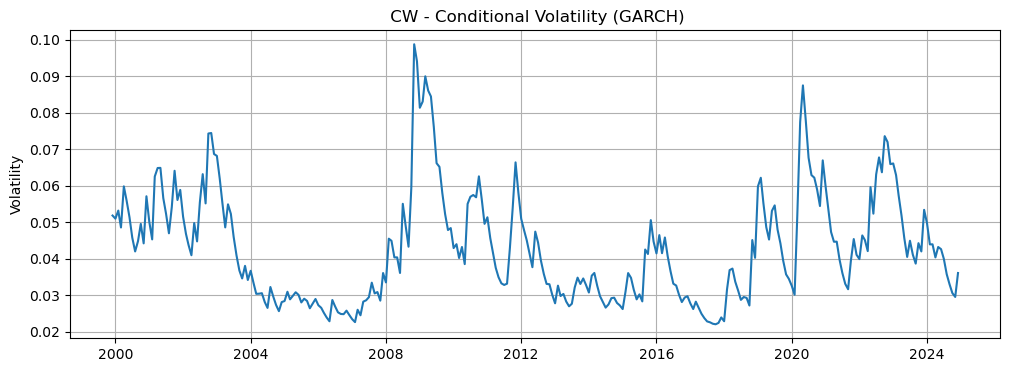

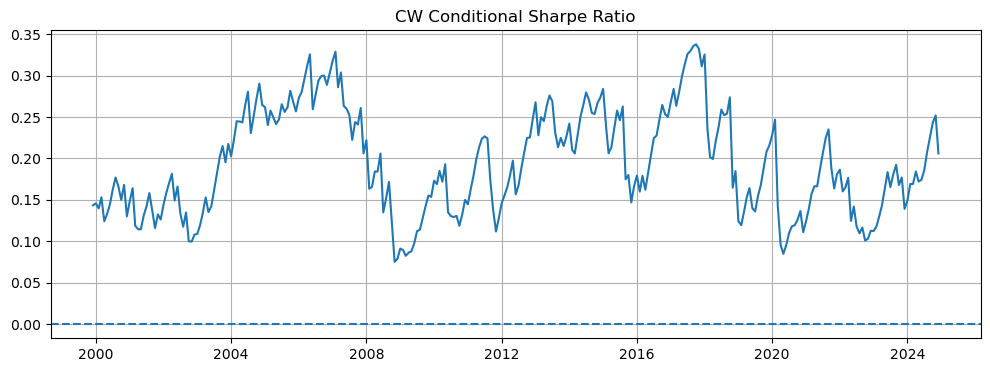

In [50]:
garch_res = fit_garch_model(portfolio)

print(garch_res.summary())


cond_vol = garch_res.conditional_volatility / 100  # scale back

plt.figure(figsize=(12,4))
plt.plot(cond_vol)
plt.title(f" {portfolio_name} - Conditional Volatility (GARCH)")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

mean_return = portfolio.mean()

cond_sharpe = mean_return / cond_vol

plt.figure(figsize=(12,4))
plt.plot(cond_sharpe)
plt.axhline(0, linestyle="--")
plt.title(f"{portfolio_name} Conditional Sharpe Ratio")
plt.grid(True)
plt.show()



